In [1]:
!pip install mysql-connector-python
!pip install matplotlib pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.9/33.9 MB 14.3 MB/s eta 0:00:00


In [12]:
import sqlite3

conn = sqlite3.connect("sale_data.db")
cursor = conn.cursor()

# Check if the table exists before creating it
cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='sales'")
table_exists = cursor.fetchone()

if not table_exists:
    cursor.execute("""
    CREATE TABLE sales (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        product TEXT NOT NULL,
        quantity INTEGER NOT NULL,
        price REAL NOT NULL
    )
    """)
    print("Table 'Sales' created successfully.")
    sample_data = [
        ('Apple', 10, 1.5),
        ('Banana', 5, 0.8),
        ('Apple', 7, 1.5),
        ('Orange', 8, 1.2),
        ('Banana', 10, 0.75),
        ('Mango', 6, 2.0),
        ('Kiwi', 2, 15.0),
        ('Pineapple', 6, 4.0),
        ('Blackberry', 3, 5.0),
        ('Strawberry', 5, 7.0),
        ('Watermelon', 2, 3.0),
        ('Papaya', 3, 1.7)
    ]
    cursor.executemany("INSERT INTO Sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
    conn.commit()
    print("Sample data inserted.")
else:
    print("Table 'Sales' already exists.")

conn.close()
print("sale_data.db accessed!")


Table 'Sales' created successfully.
Sample data inserted.
sale_data.db accessed!


      product  total_qty  revenue
0       Apple         17     25.5
1      Banana         15     11.5
2  Blackberry          3     15.0
3        Kiwi          2     30.0
4       Mango          6     12.0
5      Orange          8      9.6
6      Papaya          3      5.1
7   Pineapple          6     24.0
8  Strawberry          5     35.0
9  Watermelon          2      6.0


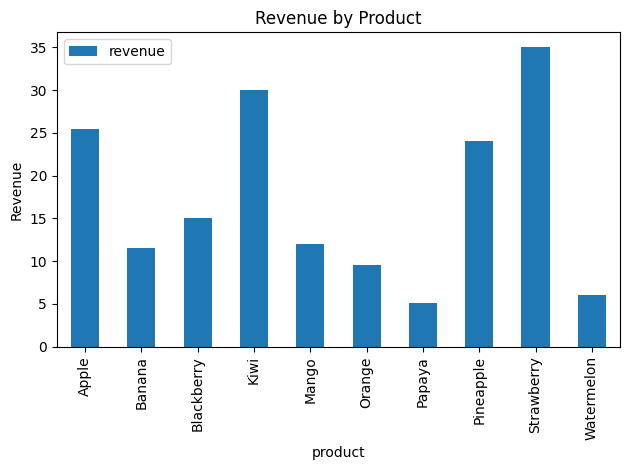

In [13]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite DB
conn = sqlite3.connect("sale_data.db")

# Run SQL query
query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM Sales
GROUP BY product
"""
df = pd.read_sql_query(query, conn)

# Display the result
print(df)

# Plot revenue by product
df.plot(kind='bar', x='product', y='revenue', title='Revenue by Product')
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sale_chart.png")
plt.show()

conn.close()


In [15]:
from google.colab import files
files.download("sale_data.db")
files.download("sale_chart.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>